In [1]:
import os 
import sys
import re 
import numpy as np 
import pandas as pd 
import plotly.graph_objects as go 

In [2]:
OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import pdb_functions as pu 
import voxel_functions as vf
import color_function as cf 
import plot_functions as pf 
import BindingCavity_functions as bc 
import SequenceAlignment_functions as sa 

In [22]:
import importlib 

importlib.reload(pf)
importlib.reload(cf)

<module 'color_function' from '/mnt/data2/Justice/OR_learning/utils/color_function.py'>

### ESM embeddings
- Compare sequence embeddings generated from ESM2 with grantham distance or AF3 rmsds

In [ ]:
seq_esm = pd.DataFrame(np.load('/mnt/data2/Justice/OR_learning/files/ESM/sequence_embeddings.npy', 
                               allow_pickle=True))

seq_esm.index = OR_seq

In [7]:
seq_esm = pd.read_csv('/mnt/data2/Justice/OR_learning/files/ESM/sequence_embeddings.csv', index_col = 0)
seq_esm = seq_esm[seq_esm.index.str.contains('^Or')]

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize for PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(seq_esm)

# Apply PCA
n_components = 2
pca = PCA(n_components=n_components)
reduced_data = pca.fit_transform(scaled_data)
variance_ratio = pca.explained_variance_ratio_

# Store results in a DataFrame
pca_df = pd.DataFrame(reduced_data, 
                      columns=[f'PCA_{i+1}' for i in range(n_components)], 
                      index=list(seq_esm.index))
# pca_df = pca_df.reset_index().rename(columns={'index': 'OR'})

print("Reduced data shape:", reduced_data.shape)
print("Explained variance ratio:", variance_ratio)



Reduced data shape: (1084, 2)
Explained variance ratio: [0.11852885 0.08020215]


##### Umaps 

In [82]:
import plotly.graph_objects as go 

# Visualize pca 
OR_name = list(pca_df.index)

# Extract OR class from index
OR_family = [re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else 'None' for _OR in pca_df.index]

# Define Class I and Class II based on OR number ranges
Class_I_df = pca_df.loc[[_OR for _OR, cls in zip(pca_df.index, OR_family) if cls in map(str, range(51, 57))]]
Class_II_df = pca_df.loc[[_OR for _OR, cls in zip(pca_df.index, OR_family) if cls in map(str, range(1, 15))]]


# Define colors for each class
colormap = cf.distinct_colors(['Class_I', 'Class_II'])

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=Class_I_df.iloc[:, 0],  # First dimension
    y=Class_I_df.iloc[:, 1],  # Second dimension
    text=Class_I_df.index,    # Labels
    mode='markers',
    name='Class_I',
    marker=dict(
        color=colormap['Class_I'],
        size = 8, opacity=0.6
    )
))

fig.add_trace(go.Scatter(
    x=Class_II_df.iloc[:, 0],
    y=Class_II_df.iloc[:, 1],
    text=Class_II_df.index,
    mode='markers',
    name='Class_II',
    marker=dict(
        color=colormap['Class_II'],
        size = 8, opacity=0.6
    )
))


fig.update_traces( marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white',  # set the plot background color to white
                  paper_bgcolor='white',  # set the paper background color to white
)
fig.show()
fig.write_html('../../output/ESM/PCA/PCA_esm_class.html')

In [ ]:
import plotly.graph_objects as go 

# Visualize pca 
OR_name = list(pca_df.index)

# Extract OR class from index
index_family = pd.Series(re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else None for _OR in pca_df.index)

# Define colors for each class
colormap = cf.distinct_colors(np.unique(index_family), category='tab20')

# Plot
fig = go.Figure()

for _family in np.sort(np.unique(index_family).astype(int)): 
    subset = pca_df.reset_index(names='OR')[index_family == str(_family)]
    
    fig.add_trace(go.Scatter(
        x=subset['PCA_1'],  # First dimension
        y=subset['PCA_2'],  # Second dimension
        text=subset['OR'],    # Labels
        mode='markers',
        name= f'family {str(_family)}',
        marker=dict(
            color=colormap[str(_family)],
            size = 8, opacity=0.6
        )
    ))


fig.update_traces( marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white',  # set the plot background color to white
                  paper_bgcolor='white',  # set the paper background color to white
)
fig.show()
fig.write_html('../../output/ESM/PCA/PCA_esm_family.html')

#### pairwise distance PCA 

In [ ]:
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

# === PCA ESM distance === 
pca_df['family'] = pd.Series((re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else None) for _OR in pca_df.index).astype(int).to_list()
pca_df = (pca_df.assign(index_col=pca_df.index)
          .sort_values(by=['family', 'index_col'])
          .drop(columns='index_col'))
pca_df.to_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/pca_esm_coords.csv') # Quick save for future use

pca_distance = pf.compute_pairwise_pca_distance(pca_df[['PCA_1', 'PCA_2']], 
                                                zscore=True, 
                                                colnames = ['OR1', 'OR2', 'ESM_Distance'])
# pca_distance['ESM_Distance'] = pca_zscore

# === MDS Grantham distance === 
mds_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/Canonical_bc/SeqAlignment/SeqAlignment_Full_grantham_dist_mtx.csv', index_col = 0)
#Reindex based on pca_df 
mds_df = mds_df[pca_df.index].loc[pca_df.index]
i, j = np.triu_indices_from(mds_df, k=1)

mds_dist = mds_df.values[i, j]
mds_zscore = (mds_dist - np.mean(mds_dist)) / np.std(mds_dist)
mds_distance = pd.DataFrame({
    "OR1": mds_df.index[i],
    "OR2": mds_df.columns[j],
    "Grantham_Distance": mds_zscore, 
})

# === Join dataframe === 
distance_df = pd.merge(pca_distance, mds_distance, on = ['OR1', 'OR2'], how='left')

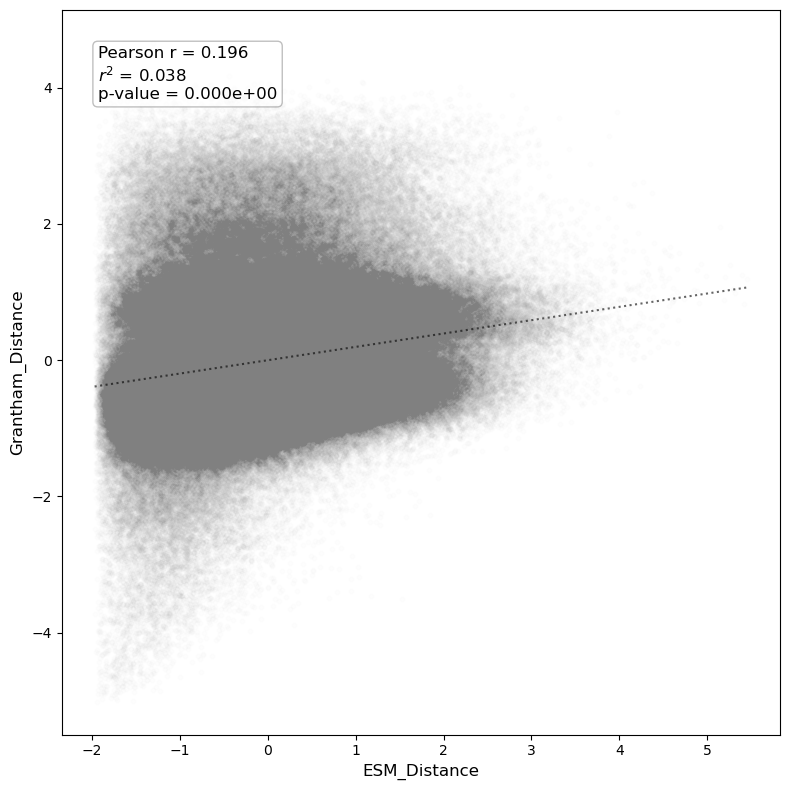

In [ ]:
plt = pf.plt_correlation(distance_df['ESM_Distance'], 
                   distance_df['Grantham_Distance'], 
                   xlabel = 'ESM_Distance', 
                   ylabel = 'Grantham_Distance',
                   opacity = 0.01)
# plt.xlim(-5, 6)
# plt.ylim(-5, 6)
plt.savefig('/mnt/data2/Justice/OR_learning/output/ESM/PCA/corr_ESM_PCAdist_grantham.png')
plt.show()


In [ ]:
import seaborn as sns 
import matplotlib.patches as mpatches

# Join ESM and MDS zscore togetehr
mask_upper = np.triu(squareform(distance_df['ESM_Distance']), k=1).astype(bool)
mask_lower = np.tril(squareform(distance_df['Grantham_Distance']), k=-1).astype(bool)

plot_df = pd.DataFrame(np.zeros_like(squareform(distance_df['ESM_Distance'])), 
                       index=pca_df.index, 
                       columns=pca_df.index)
plot_df.values[mask_upper] = pd.DataFrame(squareform(distance_df['ESM_Distance'])).values[mask_upper]
plot_df.values[mask_lower] = pd.DataFrame(squareform(distance_df['Grantham_Distance'])).values[mask_lower]

plot_df_index = pd.Series((re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else None) 
                          for _OR in plot_df.index).astype(int)


# Assign cluster colors based on family 
colors = cf.distinct_colors(plot_df_index.unique(), 
                                category='tab20')
colors = {_key: _color.upper() for _key, _color in colors.items()}
index_colors = plot_df_index.map(colors)
index_colors = [ _color.upper() for _color in index_colors]
# Assign secondary colors based on class
class_colors = sns.cubehelix_palette(2,light=.7, dark=.5, start=1, rot=3)
index_colors_class = ['#ffd8b1' if _index in range(1,15) else '#bfef45' for _index in plot_df_index]


# Create family/class name mappings for the legend
family_names = {family_id: f"Family {family_id}" for family_id in plot_df_index.unique()}
class_names = {
    '#ffd8b1': 'Class II',
    '#bfef45': 'Class I'
}

# Plot the heatmap
g = sns.clustermap(plot_df, 
               cmap = 'RdBu_r',
               center = 0, 
               cbar_pos = (0.05, 0.15, 0.03, 0.6), 
               row_colors = [index_colors, index_colors_class], 
               col_colors = [index_colors, index_colors_class],
               row_cluster = False, 
               col_cluster = False,
               figsize=(12, 10)  # Adjust figure size to accommodate legends
               )

# Add legends for the family colors
family_handles = [mpatches.Patch(color=color, label=family_names[family_id]) 
                 for family_id, color in colors.items()]
class_handles = [mpatches.Patch(color=color, label=name) 
                 for color, name in class_names.items()]

# Position the legends
# Family legend - on top left corner
family_legend = g.fig.legend(handles=family_handles, 
                            title="Family Groups",
                            loc="upper center", 
                            bbox_to_anchor=(0.5, 0.98), 
                            frameon=False,
                            ncol=3)  # Adjust number of columns as needed

# Class legend - on top right corner
class_legend = g.fig.legend(handles=class_handles, 
                           title="Class Categories",
                           loc="upper right", 
                           frameon=False,
                           bbox_to_anchor=(0.95, 0.98))

# Add a title for the entire plot
plt.suptitle("Pairwise euclidean distances between\nESM PCA (top right)\n vs.\nGrantham MDS (bottom left) ", 
             fontsize=16, x= 0.05, y=1)
g.savefig('../../output/ESM/PCA/Heatmap_ESMvsGrantham.png')


### Extract CBC ESM embeddings
In order to capture hopefully more meaningful differences between receptors against ligand prediction. The goal here is to extract ESM embeddings however, instead of aggregating all residues per OR into a single sequence embedding. Subset the residues in the binding cavity before aggregating for sequence embedding

In [5]:
# Extracted via canonical binding cavity subset of superimoposed structures 
Cbc_res = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/dict_Cbc_res_coords.pkl')

In [6]:
esm_OR = np.load('/mnt/data2/Justice/OR_learning/files/ESM/esm_OR_order.npy', allow_pickle= True)
esm_res = np.load('/mnt/data2/Justice/OR_learning/files/ESM/residue_embeddings.npy', allow_pickle= True)

# Subset for only DL_OR nomenclature ORs 
# esm_res = esm_res[pd.Series(esm_OR).str.contains('^Or')] 
# esm_OR = esm_OR[pd.Series(esm_OR).str.contains('^Or')]

# Subset for ORs contained in Cbc_res
mask = mask = [i for i, _OR in enumerate(esm_OR) if _OR in Cbc_res.keys()]
esm_res = esm_res[mask]
esm_OR = esm_OR[mask]

In [7]:
# Subsets for CBC residues in ESM residue embeddings 

import random

esm_res_shuffle = []
esm_res_cbc = []
for i, _OR in enumerate(esm_OR): 
    cbc_index_to_keep = np.unique(Cbc_res[_OR][:,0]).astype(int)-1 # -1 Due to 0 indexing 
    esm_res_cbc.append(esm_res[i][cbc_index_to_keep].mean(axis=0))
    
    shuffle_index_to_keep = np.unique(random.sample(range(len(esm_res[i])), 
                                         len(np.unique(Cbc_res[_OR][:,0]).astype(int))))
    esm_res_shuffle.append(esm_res[i][shuffle_index_to_keep].mean(axis=0))


esm_res_cbc = pd.DataFrame(np.vstack(esm_res_cbc), 
                           index = esm_OR)

esm_res_shuffle = pd.DataFrame(np.vstack(esm_res_shuffle), 
                           index = esm_OR)

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize for PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(esm_res_cbc)

# Apply PCA
n_components = 2
pca = PCA(n_components=n_components)
reduced_data = pca.fit_transform(scaled_data)
variance_ratio = pca.explained_variance_ratio_

# Store results in a DataFrame
pca_df = pd.DataFrame(reduced_data, 
                      columns=[f'PCA_{i+1}' for i in range(n_components)], 
                      index=list(esm_res_cbc.index))
# pca_df = pca_df.reset_index().rename(columns={'index': 'OR'})

print("Reduced data shape:", reduced_data.shape)
print("Explained variance ratio:", variance_ratio)



# Calculate PCA for shuffle data 
# Standardize for PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(esm_res_shuffle)

# Apply PCA
n_components = 2
pca = PCA(n_components=n_components)
reduced_data = pca.fit_transform(scaled_data)
variance_ratio = pca.explained_variance_ratio_

# Store results in a DataFrame
shuffle_pca_df = pd.DataFrame(reduced_data, 
                      columns=[f'PCA_{i+1}' for i in range(n_components)], 
                      index=list(esm_res_shuffle.index))
# pca_df = pca_df.reset_index().rename(columns={'index': 'OR'})

print("Reduced data shape:", reduced_data.shape)
print("Explained variance ratio:", variance_ratio)



Reduced data shape: (1057, 2)
Explained variance ratio: [0.07866258 0.07258143]
Reduced data shape: (1057, 2)
Explained variance ratio: [0.04808674 0.03390402]


##### Umaps

In [73]:
# Quick sanity check to make sure that the PCA is not  clustering by the number of CBC used for the embedding averaging
num_cbc_res = []
for i, _OR in enumerate(Cbc_res.keys()): 
    num_cbc_res.append(len(np.unique(Cbc_res[_OR][:,0]).astype(int)-1))
    
# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=pca_df['PCA_1'],  # First dimension
    y=pca_df['PCA_2'],  # Second dimension
    text=pca_df.index,    # Labels
    mode='markers',
    marker=dict(
        color=num_cbc_res,
        size = 8, opacity=0.6, 
        colorscale="Blues"
    )
))

fig.update_traces( marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white',  # set the plot background color to white
                  paper_bgcolor='white',  # set the paper background color to white
)
fig.show()
# fig.write_html('../../output/ESM/PCA/Cbc_esm/PCA_Cbc_esm_CbcCounts.html')

In [ ]:
# Quick sanity check to make sure that the PCA is not  clustering by the number of CBC used for the embedding averaging
num_cbc_res = []
for i, _OR in enumerate(esm_OR): 
    num_cbc_res.append(len(np.unique(Cbc_res[_OR][:,0]).astype(int)-1))
    
# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=pca_df['PCA_1'],  # First dimension
    y=pca_df['PCA_2'],  # Second dimension
    text=pca_df.index,    # Labels
    mode='markers',
    marker=dict(
        color=num_cbc_res,
        size = 8, opacity=0.6, 
        colorscale="RdBu"
    )
))

fig.update_traces( marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white',  # set the plot background color to white
                  paper_bgcolor='white',  # set the paper background color to white
)
fig.show()
fig.write_html('../../output/ESM/PCA/Cbc_esm/PCA_Cbc_esm_CbcCounts.html')

In [37]:
import plotly.graph_objects as go 

# Visualize pca 
OR_name = list(shuffle_pca_df.index)

# Extract OR class from index
OR_family = [re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else 'None' for _OR in pca_df.index]

# Define Class I and Class II based on OR number ranges
Class_I_df = shuffle_pca_df.loc[[_OR for _OR, cls in zip(shuffle_pca_df.index, OR_family) if cls in map(str, range(51, 57))]]
Class_II_df = shuffle_pca_df.loc[[_OR for _OR, cls in zip(shuffle_pca_df.index, OR_family) if cls in map(str, range(1, 15))]]


# Define colors for each class
colormap = cf.distinct_colors(['Class_I', 'Class_II'])

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=Class_I_df.iloc[:, 0],  # First dimension
    y=Class_I_df.iloc[:, 1],  # Second dimension
    text=Class_I_df.index,    # Labels
    mode='markers',
    name='Class_I',
    marker=dict(
        color=colormap['Class_I'],
        size = 8, opacity=0.6
    )
))

fig.add_trace(go.Scatter(
    x=Class_II_df.iloc[:, 0],
    y=Class_II_df.iloc[:, 1],
    text=Class_II_df.index,
    mode='markers',
    name='Class_II',
    marker=dict(
        color=colormap['Class_II'],
        size = 8, opacity=0.6
    )
))


fig.update_traces( marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white',  # set the plot background color to white
                  paper_bgcolor='white',  # set the paper background color to white
)
fig.show()
# fig.write_html('../../output/ESM/PCA/Cbc_esm/PCA_Cbc_esm_class.html')

In [10]:
import plotly.graph_objects as go 

# Visualize pca 
OR_name = list(pca_df.index)

# Extract OR class from index
OR_family = [re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else 'None' for _OR in pca_df.index]

# Define Class I and Class II based on OR number ranges
Class_I_df = pca_df.loc[[_OR for _OR, cls in zip(pca_df.index, OR_family) if cls in map(str, range(51, 57))]]
Class_II_df = pca_df.loc[[_OR for _OR, cls in zip(pca_df.index, OR_family) if cls in map(str, range(1, 15))]]


# Define colors for each class
colormap = cf.distinct_colors(['Class_I', 'Class_II'])

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=Class_I_df.iloc[:, 0],  # First dimension
    y=Class_I_df.iloc[:, 1],  # Second dimension
    text=Class_I_df.index,    # Labels
    mode='markers',
    name='Class_I',
    marker=dict(
        color=colormap['Class_I'],
        size = 8, opacity=0.6
    )
))

fig.add_trace(go.Scatter(
    x=Class_II_df.iloc[:, 0],
    y=Class_II_df.iloc[:, 1],
    text=Class_II_df.index,
    mode='markers',
    name='Class_II',
    marker=dict(
        color=colormap['Class_II'],
        size = 8, opacity=0.6
    )
))


fig.update_traces( marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white',  # set the plot background color to white
                  paper_bgcolor='white',  # set the paper background color to white
)
fig.show()
fig.write_html('../../output/ESM/PCA/Cbc_esm/PCA_Cbc_esm_class.html')

In [11]:
import plotly.graph_objects as go 

# Visualize pca 
OR_name = list(pca_df.index)

# Extract OR class from index
index_family = pd.Series(re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else None for _OR in pca_df.index)

# Define colors for each class
colormap = cf.distinct_colors(np.unique(index_family), category='tab20')

# Plot
fig = go.Figure()

for _family in np.sort(np.unique(index_family).astype(int)): 
    subset = pca_df.reset_index(names='OR')[index_family == str(_family)]
    
    fig.add_trace(go.Scatter(
        x=subset['PCA_1'],  # First dimension
        y=subset['PCA_2'],  # Second dimension
        text=subset['OR'],    # Labels
        mode='markers',
        name= f'family {str(_family)}',
        marker=dict(
            color=colormap[str(_family)],
            size = 8, opacity=0.6
        )
    ))


fig.update_traces( marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white',  # set the plot background color to white
                  paper_bgcolor='white',  # set the paper background color to white
)
fig.show()
fig.write_html('../../output/ESM/PCA/Cbc_esm/PCA_Cbc_esm_family.html')

##### Pairwise distance comparison 

In [9]:
from scipy.spatial.distance import pdist
from itertools import combinations

# Combines both Full_PCA_ESM vs CBC_PCA_ESM

# === PCA ESM distance === 
pca_df['family'] = pd.Series((re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else None) for _OR in pca_df.index).astype(int).to_list()
pca_df = (pca_df.assign(index_col=pca_df.index)
          .sort_values(by=['family', 'index_col'])
          .drop(columns='index_col'))
# pca_df.to_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/Cbc_esm/pca_Cbc_esm_coords.csv') # Quick save for future use
# pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/Cbc_esm/pca_Cbc_esm_coords.csv', index_col = 0)

# Compute pairwise distances (returns condensed form)
pca_dist = pdist(pca_df[['PCA_1', 'PCA_2']], metric='euclidean')
pca_zscore = (pca_dist - np.mean(pca_dist)) / np.std(pca_dist)

# Get PCA from Full sequence embedding 
pca_full = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/pca_esm_coords.csv', index_col = 0)
pca_full = pca_full[pca_full.index.isin(pca_df.index)] # Ensure the same ORs. 
pca_dist = pdist(pca_full[['PCA_1', 'PCA_2']], metric='euclidean')
full_pca_zscore = (pca_dist - np.mean(pca_dist)) / np.std(pca_dist)

# Get PCA from shuffle embedding 
pca_dist = pdist(shuffle_pca_df[['PCA_1', 'PCA_2']], metric='euclidean')
shuffle_pca_zscore = (pca_dist - np.mean(pca_dist)) / np.std(pca_dist)

# Get pairwise indices for upper triangle
or_names = pca_df.index.to_list()
pairs = list(combinations(or_names, 2))  

# Create labeled DataFrame
pca_distance = pd.DataFrame(pairs, columns=['OR1', 'OR2'])
pca_distance['Cbc_ESM_Distance'] = pca_zscore
pca_distance['Full_ESM_Distance'] = full_pca_zscore
pca_distance['Shuffle_ESM_Distance'] = shuffle_pca_zscore

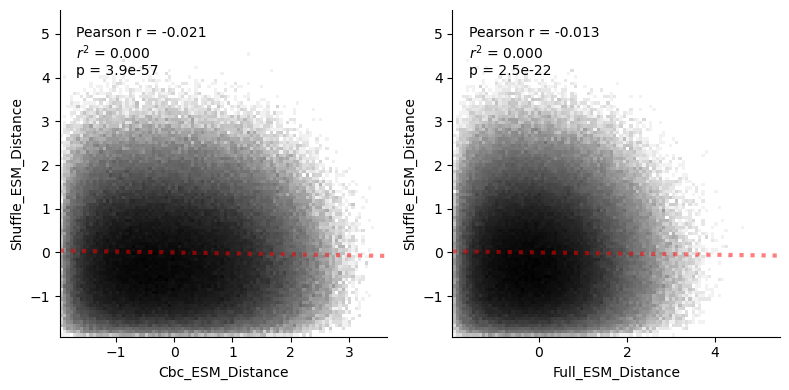

In [36]:
# Sanity check to see how random residues from each OR ESM correlates with full residue ESM

fig, ax = pf.plt_correlation_subplots([[pca_distance['Cbc_ESM_Distance'], pca_distance['Shuffle_ESM_Distance']], 
                                       [pca_distance['Full_ESM_Distance'], pca_distance['Shuffle_ESM_Distance']]], 
                                      xlabels = ['Cbc_ESM_Distance', 'Full_ESM_Distance'], 
                                      ylabels = ['Shuffle_ESM_Distance', 'Shuffle_ESM_Distance'],
                                      plot_style = 'hist2d', cmap='Greys',
                                      linecolor='Red', linewidth=3,
                                      pearson_fontsize=10,
                                      ncols=2, figsize_per_plot=[4,4])
fig.savefig('/mnt/data2/Justice/OR_learning/output/ESM/PCA/corr_ESM_PCAdist_Cbc_shuffle.png')


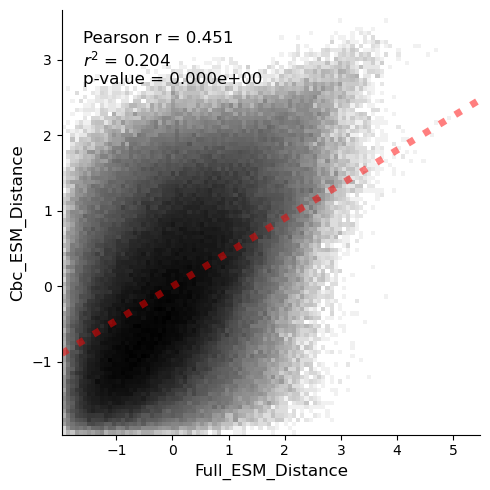

In [25]:
fig, ax = pf.plt_correlation(pca_distance['Full_ESM_Distance'], 
                             pca_distance['Cbc_ESM_Distance'], 
                             xlabel = 'Full_ESM_Distance', 
                             ylabel = 'Cbc_ESM_Distance',
                             plot_style = 'hist2d', cmap='Greys',
                             linecolor='Red', linewidth=5,
                             figsize=[5,5])
fig.savefig('/mnt/data2/Justice/OR_learning/output/ESM/PCA/corr_ESM_PCAdist_Cbc_Full.png')
fig.show()

### ESM vs ligand response

#### TEST case 
Hypothesis is that if ESM encodes odor responsiveness... 
In the case of pS6-IP does acetophenone(7410) responding ORs have less ESM pairwise distance than random ? 

In [56]:
# Quickly generate Cbc ESM PCA pairwise distance dataframe

from itertools import combinations
from scipy.spatial.distance import pdist

# Cbc ESM PCA
pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/Cbc_esm/pca_Cbc_esm_coords.csv', index_col = 0) 

# Compute pairwise distances (returns condensed form)
pca_dist = pdist(pca_df[['PCA_1', 'PCA_2']], metric='euclidean')
pca_zscore = (pca_dist - np.mean(pca_dist)) / np.std(pca_dist)
or_names = pca_df.index.to_list()
pairs = list(combinations(or_names, 2))  

# Create labeled DataFrame
pca_distance = pd.DataFrame(pairs, columns=['OR1', 'OR2'])
pca_distance['ESM_Distance'] = pca_dist
pca_distance['ESM_Distance_zscore'] = pca_zscore

In [10]:
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv')
ps6_df = ps6_df[['DL_OR', 'cid', 'odor', 'concentration', 'odor_and_conc', 'odor_category', 'logFC', 'FDR']]
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
# Quick sort to make plots group by odor category etc. 
ps6_df = ps6_df.sort_values(['odor_category', 'odor', 'concentration', 'FDR'])

In [ ]:
# Bar plot to show ESM euclidean distance between OR responding to the same ligands via pS6


fig = go.Figure()

# Randomly sample same number of comparisons for shuffled control
OR_mask = random.sample(list(ps6_df.DL_OR.unique()), 
                        50)
shuffled_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
                             (pca_distance.OR2.isin(OR_mask))]

# Shuffled control bar
fig.add_trace(go.Violin(
    x=['Shuffled'] * len(shuffled_data),
    y=shuffled_data['ESM_Distance'],
    # error_y=dict(type='data', array=[shuffled_data['ESM_Distance'].std()]),
    name='Shuffled',
    marker=dict(color='#D3D3D3', opacity=1),
    # offsetgroup='Shuffled',
    legendgroup='Shuffled'
))

# colormap = cf.distinct_colors(ps6_df.odor_category.unique(), category = 'tab10')
category_colors = cf.distinct_colors(ps6_df.odor_category.unique(), category = 'tab10')
colormap = {}
for _category in ps6_df.odor_category.unique():     
    colormap.update(cf.generate_faded_shades(category_colors[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].odor.unique())))


for _odor in ps6_df.odor.unique(): 
    
    # Subset: DL_OR comparisons
    ps6_subset = ps6_df[(ps6_df.odor == _odor) & 
                        (ps6_df.FDR < 0.05) & 
                        (ps6_df.logFC > 1)]
    if len(ps6_subset) <= 2: 
        continue
    
    cid = ps6_subset.cid.unique().astype(str).item()
    odor_group = ps6_subset.odor_category.unique().item()
    # concentration = ps6_subset.concentration.unique().astype(str).item()
    OR_mask = ps6_subset.DL_OR
    
    odor_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
                            (pca_distance.OR2.isin(OR_mask))]
    
    fig.add_trace(go.Violin(
        x=[cid] * len(odor_data),
        y=odor_data['ESM_Distance'].values,
        name=f'{_odor} ({cid})',
        # mode = 'markers', 
        marker=dict(color=colormap[_odor],
                    opacity=0.5),
        # offsetgroup=concentration,
        legendgroup=cid
    ))
    
from scipy import stats  
label = []
label_symbols = []
for _pairs in [[0,i] for i in range(len(fig.data))]:
    tstat, pvalue = stats.ttest_ind(
        fig['data'][_pairs[0]]['y'],
        fig['data'][_pairs[1]]['y'],
        equal_var=False)
    if pvalue < 0.05: 
        label.append([_pairs[1], _pairs[1]])
        label_symbols.append(pf.format_pvalue(pvalue, p_round=1, 
                                              show='symbol'
                                              ))
        
fig = pf.add_p_value_annotation(fig, 
                                label, 
                                just_annotate = label_symbols, 
                                y_padding=False,
                                font_size=10, 
                                _format=dict(interline=0.00, text_height=1, color='black'))
# fig = pf.add_p_value_annotation(fig, 
#                                 [[0,i] for i in range(len(fig.data))], 
#                                 test_type='ttest_ind', 
#                                 # popmean = 0,  
#                                 # include_tstat=True, 
#                                 # y_padding=False, 
#                                 font_size=10,
#                                 show='symbol',
#                                 p_round=2, 
#                                 _format=dict(interline=0.00, text_height=1, color='black'))

fig.add_hline(y=shuffled_data['ESM_Distance'].mean(), line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)

fig.update_layout(
    title="ESM PCA pairwise euclidean distance for pS6-IP odor responding ORs <br><sup>ttest_ind against shuffle",
    yaxis_title="ESM pairwise euclidean distance",
    xaxis_title="",
    barmode='group'
)

fig.update_layout(template = 'simple_white')
fig.show()

fig.write_html('/mnt/data2/Justice/OR_learning/output/ESM/PCA/Cbc_esm/Cbc_esm_pairwise_odorOR_PCAdist.html')

In [ ]:
import random

# Bar plot to show ESM euclidean distance between OR responding to the same ligands via pS6
fig = go.Figure()

# Randomly sample same number of comparisons for shuffled control
# OR_mask = random.sample(list(ps6_df.DL_OR.unique()), 50)
# shuffled_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
#                              (pca_distance.OR2.isin(OR_mask))]
shuffled_data = pca_distance.sample(200)


# Shuffled control bar
fig.add_trace(go.Violin(
    x=['Shuffled'] * len(shuffled_data),
    y=shuffled_data['ESM_Distance_zscore'],
    # error_y=dict(type='data', array=[shuffled_data['ESM_Distance'].std()]),
    name='Shuffled',
    marker=dict(color='#D3D3D3', opacity=1),
    # offsetgroup='Shuffled',
    legendgroup='Shuffled'
))

# colormap = cf.distinct_colors(ps6_df.odor_category.unique(), category = 'tab10')
category_colors = cf.distinct_colors(ps6_df.odor_category.unique(), category = 'tab10')
colormap = {}
for _category in ps6_df.odor_category.unique():     
    colormap.update(cf.generate_faded_shades(category_colors[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].odor.unique())))


for _odor in ps6_df.odor.unique(): 
    
    # Subset: DL_OR comparisons
    ps6_subset = ps6_df[(ps6_df.odor == _odor) & 
                        (ps6_df.FDR < 0.05) & 
                        (ps6_df.logFC > 1)]
    if len(ps6_subset) <= 2: 
        continue
    
    cid = ps6_subset.cid.unique().astype(str).item()
    odor_group = ps6_subset.odor_category.unique().item()
    # concentration = ps6_subset.concentration.unique().astype(str).item()
    OR_mask = ps6_subset.DL_OR
    
    odor_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
                            (pca_distance.OR2.isin(OR_mask))]
    
    fig.add_trace(go.Violin(
        x=[cid] * len(odor_data),
        y=odor_data['ESM_Distance_zscore'].values,
        name=f'{_odor} ({cid})',
        # mode = 'markers', 
        marker=dict(color=colormap[_odor],
                    opacity=0.5),
        # offsetgroup=concentration,
        legendgroup=cid
    ))
fig = pf.add_p_value_annotation(fig, 
                                [[i,i] for i in range(len(fig.data))], 
                                test_type='ttest_1samp', popmean = 0,  
                                # include_tstat=True, 
                                y_padding=False, 
                                font_size=10,
                                show='symbol',
                                p_round=2, 
                                _format=dict(interline=0.07, text_height=1, color='black'))

fig.add_hline(y=0, line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)

fig.update_layout(
    title="ESM PCA pairwise euclidean distance for pS6-IP odor responding ORs <br><sup>ttest_1samp against mean=0",
    yaxis_title="ESM pairwise euclidean distance z-scored",
    xaxis_title="",
    barmode='group'
)

fig.update_layout(template = 'simple_white')
fig.show()
fig.write_html('/mnt/data2/Justice/OR_learning/output/ESM/PCA/Cbc_esm/Cbc_esm_pairwise_odorOR_PCAzscore.html')

In [180]:
data = pd.DataFrame()
for _odor_and_conc in ps6_df.odor_and_conc.unique(): 
    
    # Subset: DL_OR comparisons
    ps6_subset = ps6_df[(ps6_df.odor_and_conc == _odor_and_conc) & 
                     (ps6_df.FDR < 0.05) & 
                     (ps6_df.logFC > 1)]
    if len(ps6_subset) <= 1: 
        continue
    
    cid = ps6_subset.cid.unique().astype(str).item()
    concentration = ps6_subset.concentration.unique().astype(str).item()
    OR_mask = ps6_subset.DL_OR
    
    odor_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) & 
                             (pca_distance.OR2.isin(OR_mask))]
    
    data = pd.concat([data, 
               pd.DataFrame([[cid, _odor_and_conc, 
                              len(OR_mask),
                              odor_data['ESM_Distance'].mean(), 
                              odor_data['ESM_Distance'].std()]], 
                            columns = ['cid', 'odor_and_conc', 'OR_counts', 'ESM_Distance_mean', 'ESM_Distance_std']
                            )]
                     )


In [350]:
data.sort_values('ESM_Distance_mean', ascending=False).OR_counts.describe()

count     60.000000
mean      20.866667
std       26.099202
min        2.000000
25%        6.000000
50%       12.500000
75%       22.500000
max      156.000000
Name: OR_counts, dtype: float64